# Master Recession Curve — interactive analysis

Step through the MRC pipeline stage by stage, inspect intermediate results, and
tune the config **before** committing to the full batch run. Each stage reads
the `cfg` object from the *Configure* cell, so to re-tune: edit `OVERRIDES`,
re-run that cell, then re-run the stages below.

Pipeline: `io → filter → recession_id → mrc → temporal`. The package lives in
`ess-project/mrc_analysis/` and is imported in place (no install).

> **Workflow:** run top-to-bottom once on the built-in synthetic record to see
> everything work, then point `io.streamflow.path` at your gauge CSV and re-tune.

In [43]:
# --- Bootstrap: put the mrc_analysis package on the path -----------------
import sys
from pathlib import Path

def _find_mrc_analysis(start: Path) -> Path:
    for base in [start, *start.parents]:
        cand = base / "mrc_analysis" / "mrc" / "config.py"
        if cand.exists():
            return base / "mrc_analysis"
        cand = base / "ess-project" / "mrc_analysis" / "mrc" / "config.py"
        if cand.exists():
            return base / "ess-project" / "mrc_analysis"
    raise FileNotFoundError("Could not locate mrc_analysis/ above " + str(start))

PKG = _find_mrc_analysis(Path.cwd())
sys.path.insert(0, str(PKG))
print("Using package at:", PKG)

Using package at: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/mrc_analysis


In [44]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mrc.config import load_config
from mrc import io as mio
from mrc import filter as mfilter
from mrc import recession_id as rid
from mrc import mrc as mmrc
from mrc import temporal as mtemporal
from mrc import plotting as mplot

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configure

`OVERRIDES` is deep-merged over `config/default.yaml`. Edit it, re-run this cell,
then re-run the stages below. To analyze real data, set
`io.streamflow.path` (and optionally `io.forcing.path`); leaving it `None` uses
a reproducible synthetic 50-year record.

Things to play around with:
1. `quickflow_frac_max`: values above this threshold will be classified as quickflow. Springtime meltout would have a high f/Q ratio. default = 0.10
2. `min_segment_length`: the minimum number of days a recession curve can be. default = 10
3. `drop_days_after_peak`: the number of days to automatically drop after a hydrograph peaks. default = 3 
4. `flow_threshold`: the fraction of mean post-melt mean Q that streamflow must be below to be considered in a "recession phase"
5. `min_tail_r2`: the coeffiecnt of determiniation 
6. `master_poly_order`: value of 1 = linear, >1 is a non-linear function. If values >1 still look linear enough, the MRC is robust and a linear reservoir can be reasonably assumed

In [85]:
CONFIG_PATH = PKG / "config" / "tuolumne_model.yaml"

Q_PATH = "/scratch/dlhogan/ess-project-data/streamflow-data/EastRiver/EastRiver_dailyDischarge_WY1970_2025.csv" 
Q_PATH_MOD = "/scratch/dlhogan/ess-project-data/streamflow-data/EastRiver/EastRiver_SUMMA_baseline_dailyDischarge_1981_2025.csv"
# Q_PATH_MOD = "/scratch/dlhogan/ess-project-data/streamflow-data/TuolumneRiver/TuolumneRiver_SUMMA_baseline_dailyDischarge_1981_2025.csv"
# Q_PATH ="/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/streamflow/preprocessed/Tuolumne_River_lumped_streamflow_processed.csv"
# Q_PATH = "/scratch/dlhogan/ess-project-data/streamflow-data/TuolumneRiver/TuolumneStreamflow_Hydroclimate_2002_2021.csv"
SWE_PATH = "/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL/380_Butte_sntl_obs.csv" 
# SWE_PATH ="/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/formatted/snotel_swe.csv"


In [86]:

# Edit these, then re-run this cell and the stages below.
OVERRIDES = {
    "io": {
        "streamflow": {
            # "path": Q_PATH_MOD,        # e.g. "/path/to/usgs_daily.csv"; None -> synthetic
            # "format": "usgs_rdb",   # or "generic" with date_col / flow_col / flag_col
            # "date_col": "Date", # time for East
            # "flow_col": "Estimated_Discharge_T120", # Estimated_Discharge_T120 for Nested; discharge for East
        },
    #     "forcing": {
    #         "path": SWE_PATH,          # optional daily precip/swe/tair CSV
    #         "swe_col": "value"},  # optional daily precip/swe/tair CSV
    },
    "recession": {
        # "dqdt_tolerance": 0.05,
        # "quickflow_frac_max": 0.10,   # gate: screening f/Q must be below this
        # "min_segment_length": 10,
        "drop_days_after_peak": 3,
        # "season": {
        #     # "mode": "fixed",          # "fixed" | "swe_meltout"
        #     # "doy_start": 182, "doy_end": 335,
        #     # Dynamic snowmelt-driven start: per water year, season begins
        #     # buffer_days after the SWE meltout date. To enable, set:
        #       "mode": "swe_meltout",
        #       "meltout": {"swe_path": SWE_PATH, "buffer_days": 14},
        },
    # },
    "mrc": {
        # "tail_method": "flow_threshold",  # "flow_threshold" | "fraction"
        # "tail_flow_frac": 0.67,          # (flow_threshold) keep Q < 2/3 * mean(recession Q)
        # "tail_fraction": 0.5,             # (fraction) late fraction of points
        # "min_tail_r2": 0.70,
        "master_poly_order": 1,           # 1 = single-exponential master
    },
    # "temporal": {
    #     # "window": {"length_years": 5, "step_years": 5, "min_recessions": 3},
    # },
    "baseflow": {
        "alpha": 0.975,                # recession/filter parameter
        # "passes": 3,                 # forward-backward-forward = 3 (reported separation/BFI)
        # "screen_passes": 1,          # passes used for the recession GATE's quickflow fraction.
        #                              # A single forward pass gives ~0 quickflow on a clean
        #                              # pure recession, which would defeat the gate. The full
        #                              # `passes` separation is still reported for BFI.
    },
}

In [87]:
cfg = load_config(path=CONFIG_PATH, overrides=OVERRIDES) # overrides=OVERRIDES; uncomment cell above to override
print("streamflow path :", cfg.io.streamflow.path or "(synthetic)")
print("gate f/Q <=     :", cfg.recession.quickflow_frac_max)
print("season doy      :", cfg.recession.season.doy_start, "->", cfg.recession.season.doy_end)
print("window          :", cfg.temporal.window.length_years, "yr /",
      cfg.temporal.window.step_years, "yr step")

streamflow path : /scratch/dlhogan/ess-project-data/streamflow-data/TuolumneRiver/TuolumneRiver_SUMMA_baseline_dailyDischarge_1981_2025.csv
gate f/Q <=     : 0.1
season doy      : 182 -> 335
window          : 5 yr / 5 yr step


## 2. Load data & inspect

Loads streamflow (+ optional forcing), reindexes onto a gap-free daily grid, and
reports gaps. Gaps are **never interpolated** — recession segments break at them.

In [88]:
flow = mio.load_streamflow(cfg)
forcing = mio.load_forcing(cfg)
df = mio.merge_forcing(flow, forcing)

gaps = mio.summarize_gaps(mio.detect_gaps(df, "Q"))
print(f"Record: {df.index.min().date()} -> {df.index.max().date()}  ({len(df)} days)")
print(f"Forcing provided: {forcing is not None}")
print(f"Gaps: {len(gaps)} runs, {int(gaps['length_days'].sum()) if len(gaps) else 0} missing days")
df.head()

Record: 1981-01-01 -> 2023-09-30  (15613 days)
Forcing provided: False
Gaps: 50 runs, 426 missing days


,Q
date,
1981-01-01,5.512487
1981-01-02,12.968543
1981-01-03,13.619956
1981-01-04,13.308715
1981-01-05,12.957038


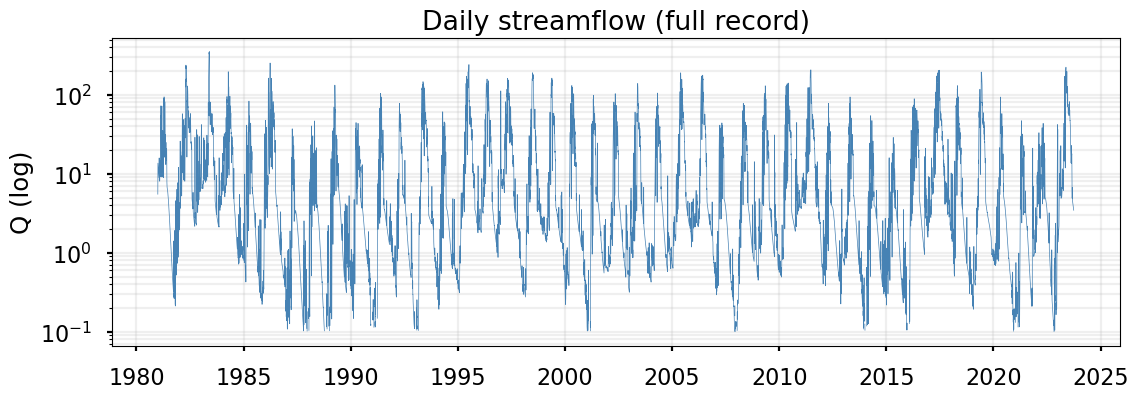

In [90]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df["Q"], lw=0.5, color="steelblue")
ax.set_yscale("log")
ax.set_ylabel("Q (log)"); ax.set_title("Daily streamflow (full record)")
ax.grid(True, which="both", alpha=0.2)

## 2a. Lag autocorrelation of 7-day minimum mean flow 

      coef     se      p  std_beta    VIF
lag                                      
0    0.333  0.152  0.049     0.449  1.446
1   -0.164  0.154  0.307    -0.223  1.513
2   -0.325  0.156  0.059    -0.422  1.415
3   -0.408  0.150  0.019    -0.532  1.320
4   -0.115  0.151  0.459    -0.155  1.410
5    0.349  0.152  0.041     0.469  1.445

adj R2 = 0.478, N = 19
saved


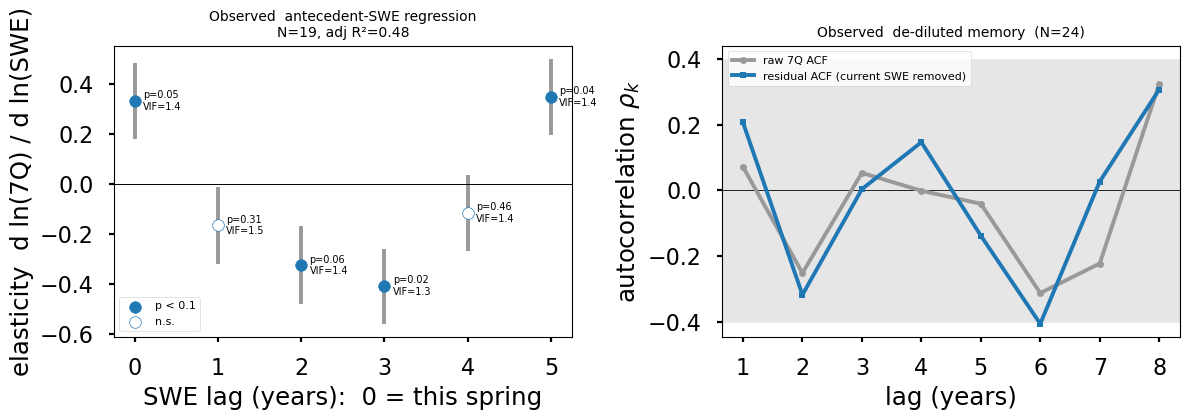

In [91]:
"""
Antecedent-snowpack memory in late-summer low flow.

Tests whether peak SWE from 1..K years ago still influences this year's
Aug-Oct 7Q *after* accounting for the current year's snowpack -- i.e. whether
the store carries multi-year memory, attributed to specific antecedent years.

Two complementary tests:
  (1) distributed-lag regression   q7(t) ~ SWE(t) + SWE(t-1) + ... + SWE(t-K)
      significant coefficients beyond lag 0 = carryover the current melt
      does not explain. Reported as elasticities (log-log) with SE, p, and
      variance-inflation factors (collinearity guard).
  (2) residual-ACF de-dilution     remove current-year SWE from q7, then
      autocorrelate the residual. Persistence surviving in the residual is
      the store's memory with this-year forcing stripped out.

Design choices (match the memory-spectrum analysis):
  - log-transform (both skewed, strictly positive; coeffs become elasticities)
  - linear detrend of each series (a shared warming trend can't fake a lag link)
  - alignment: SWE(t) = this spring's peak -> q7(t) = this summer's low flow

Runs identically on:
  observed : Butte peak SWE + gauge Aug-Oct 7Q
  modeled  : basin-mean SWE + routed Aug-Oct 7Q
so the observed regression is the corroborating check and the modeled one the
undiluted test on basin-wide input.

CAVEAT: with N ~ 44 and a single-point SWE index, lags 4-5 sit at the edge of
what the data support -- report them as caveat, not claim.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BLUE, GREY = "#1f77b4", "0.6"


# --------------------------------------------------------------------------- #
# helpers
# --------------------------------------------------------------------------- #
def _detrend(y):
    t = np.arange(len(y))
    good = np.isfinite(y)
    coef = np.polyfit(t[good], y[good], 1)
    return y - np.polyval(coef, t)


def _ols(X, y):
    """Plain OLS with SE, t, p, R2. X includes no intercept; one is added."""
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, p = X.shape
    dof = n - p
    s2 = (resid @ resid) / dof
    XtXinv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(s2 * XtXinv))
    tvals = beta / se
    pvals = 2 * stats.t.sf(np.abs(tvals), dof)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - resid @ resid / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / dof
    return dict(beta=beta, se=se, t=tvals, p=pvals, r2=r2, adj_r2=adj_r2,
                n=n, dof=dof, resid=resid)


def _vif(cols):
    """Variance inflation factor per predictor column (array of arrays)."""
    M = np.column_stack(cols)
    out = []
    for j in range(M.shape[1]):
        others = np.delete(M, j, axis=1)
        fit = _ols(others, M[:, j])
        out.append(1.0 / max(1e-9, 1.0 - fit["r2"]))
    return out


def build_design(swe, q7, max_lag=5, log=True, detrend=True):
    """Align SWE and 7Q by calendar year, build lagged predictors.

    swe, q7 : year-indexed pd.Series (index = calendar year of melt season /
              low-flow season). Returns (design_df, y, meta).
    """
    swe = swe.dropna().astype(float)
    q7 = q7.dropna().astype(float)
    yrs = range(min(swe.index.min(), q7.index.min()),
                max(swe.index.max(), q7.index.max()) + 1)
    df = pd.DataFrame(index=list(yrs))
    df["swe"] = swe.reindex(df.index)
    df["q7"] = q7.reindex(df.index)

    if log:
        df["swe"] = np.log(df["swe"]); df["q7"] = np.log(df["q7"])

    for k in range(max_lag + 1):
        df[f"swe_lag{k}"] = df["swe"].shift(k)     # SWE(t-k) aligned to q7(t)

    cols = [f"swe_lag{k}" for k in range(max_lag + 1)]
    d = df[["q7"] + cols].dropna()
    y = d["q7"].values.copy()
    X = {c: d[c].values.copy() for c in cols}

    if detrend:                                    # detrend response + each lag
        y = _detrend(y)
        X = {c: _detrend(v) for c, v in X.items()}

    meta = dict(years=d.index.values, log=log, detrend=detrend, max_lag=max_lag)
    return X, y, meta


# --------------------------------------------------------------------------- #
# main analyses
# --------------------------------------------------------------------------- #
def distributed_lag(swe, q7, max_lag=5, log=True, detrend=True):
    X, y, meta = build_design(swe, q7, max_lag, log, detrend)
    cols = list(X.keys())
    Xmat = np.column_stack([X[c] for c in cols])
    fit = _ols(Xmat, y)
    vifs = _vif([X[c] for c in cols])
    ystd = y.std(ddof=1)

    rows = []
    for i, c in enumerate(cols):                   # i+1 in beta (0 = intercept)
        b = fit["beta"][i + 1]
        rows.append({
            "lag": int(c.replace("swe_lag", "")),
            "coef": b, "se": fit["se"][i + 1], "p": fit["p"][i + 1],
            "std_beta": b * X[c].std(ddof=1) / ystd,   # comparable across lags
            "VIF": vifs[i],
        })
    tab = pd.DataFrame(rows).set_index("lag")
    tab.attrs.update(N=fit["n"], r2=fit["r2"], adj_r2=fit["adj_r2"],
                     dof=fit["dof"], meta=meta)
    return tab


def residual_acf(swe, q7, max_lag=8, log=True, detrend=True):
    """Remove current-year SWE from q7, autocorrelate residual vs raw q7."""
    X, y, meta = build_design(swe, q7, 0, log, detrend)     # only lag0 needed
    lag0 = X["swe_lag0"]
    fit = _ols(lag0.reshape(-1, 1), y)
    resid = fit["resid"]                            # carryover part, forcing out

    def acf(a, L):
        a = a - a.mean()
        out = []
        for k in range(1, L + 1):
            if len(a) - k < 4:
                break
            r, p = stats.pearsonr(a[k:], a[:-k])
            out.append({"lag": k, "rho": r, "p": p})
        return pd.DataFrame(out).set_index("lag")

    raw = acf(y, max_lag)
    res = acf(resid, max_lag)
    band = 1.96 / np.sqrt(len(y))
    return raw, res, band, len(y)


# --------------------------------------------------------------------------- #
# plotting
# --------------------------------------------------------------------------- #
def plot_memory(swe, q7, label="", max_lag=5, acf_lag=8, log=True, detrend=True):
    tab = distributed_lag(swe, q7, max_lag, log, detrend)
    raw, res, band, N = residual_acf(swe, q7, acf_lag, log, detrend)

    fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4.3))

    # (a) elasticity vs lag
    lags = tab.index.values
    sig = tab["p"].values < 0.1
    a.axhline(0, color="k", lw=0.7)
    a.errorbar(lags, tab["coef"].values, yerr=tab["se"].values, fmt="none",
               ecolor=GREY, capsize=3, zorder=1)
    a.scatter(lags[sig], tab["coef"].values[sig], color=BLUE, s=70, zorder=3,
              label="p < 0.1")
    a.scatter(lags[~sig], tab["coef"].values[~sig], facecolor="white",
              edgecolor=BLUE, s=70, zorder=3, label="n.s.")
    for k, c, p, v in zip(lags, tab["coef"], tab["p"], tab["VIF"]):
        a.annotate(f"p={p:.2f}\nVIF={v:.1f}", (k, c), fontsize=7,
                   textcoords="offset points", xytext=(6, 0), va="center")
    a.set_xticks(lags)
    a.set_xlabel("SWE lag (years):  0 = this spring")
    a.set_ylabel("elasticity  d ln(7Q) / d ln(SWE)" if log else "coef")
    a.set_title(f"{label}  antecedent-SWE regression\n"
                f"N={tab.attrs['N']}, adj R²={tab.attrs['adj_r2']:.2f}", fontsize=10)
    a.legend(fontsize=8, loc="best")

    # (b) raw vs residual ACF
    b.axhspan(-band, band, color="0.9", zorder=0)
    b.axhline(0, color="k", lw=0.6)
    b.plot(raw.index, raw["rho"], "o-", color=GREY, ms=5, label="raw 7Q ACF")
    b.plot(res.index, res["rho"], "s-", color=BLUE, ms=5,
           label="residual ACF (current SWE removed)")
    b.set_xlabel("lag (years)"); b.set_ylabel(r"autocorrelation $\rho_k$")
    b.set_title(f"{label}  de-diluted memory  (N={N})", fontsize=10)
    b.set_xticks(raw.index); b.legend(fontsize=8)

    fig.tight_layout()
    return fig, tab


# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    # synthetic: impose TRUE memory at lags 0,1,2 (weights 0.55,0.30,0.15),
    # nothing at 3-5, and confirm the regression recovers exactly that.
    yrs = np.arange(1981, 2025)
    swe = pd.read_csv(SWE_PATH, index_col=0, parse_dates=True)['SWE']
    swe.index = pd.to_datetime(swe.index).tz_localize(None)
    # capture peak swe each year
    swe = swe.groupby(swe.index.year).max()
    w = {0: 0.55, 1: 0.30, 2: 0.15}
    
    q7 = pd.read_csv(Q_PATH, index_col=0, parse_dates=True)['discharge']
    # annual low flow
    q7.index = pd.to_datetime(q7.index).tz_localize(None)
    # rolling 7-day minimum for each year
    q7_rolling = q7.rolling(window=7, min_periods=1).min()
    # only include sep-oct timing
    q7 = q7_rolling[q7_rolling.index.month.isin([11])].groupby(q7_rolling[q7_rolling.index.month.isin([11])].index.year).min()

    # reduce to pre 2000 period
    swe = swe[swe.index > 2000]
    q7 = q7[q7.index > 2000]
    tab = distributed_lag(swe, q7, max_lag=5)
    print(tab.round(3).to_string())
    print(f"\nadj R2 = {tab.attrs['adj_r2']:.3f}, N = {tab.attrs['N']}")
    fig, _ = plot_memory(swe, q7, label="Observed")
    print("saved")

## 3. Baseflow separation (screening)

Lyne-Hollick filter. `baseflow`/`quickflow` use the multi-pass separation (for
BFI); `qf_frac` is the **single-pass screening** fraction used by the recession
gate (≈0 on a clean recession). Zoom to one season to sanity-check.

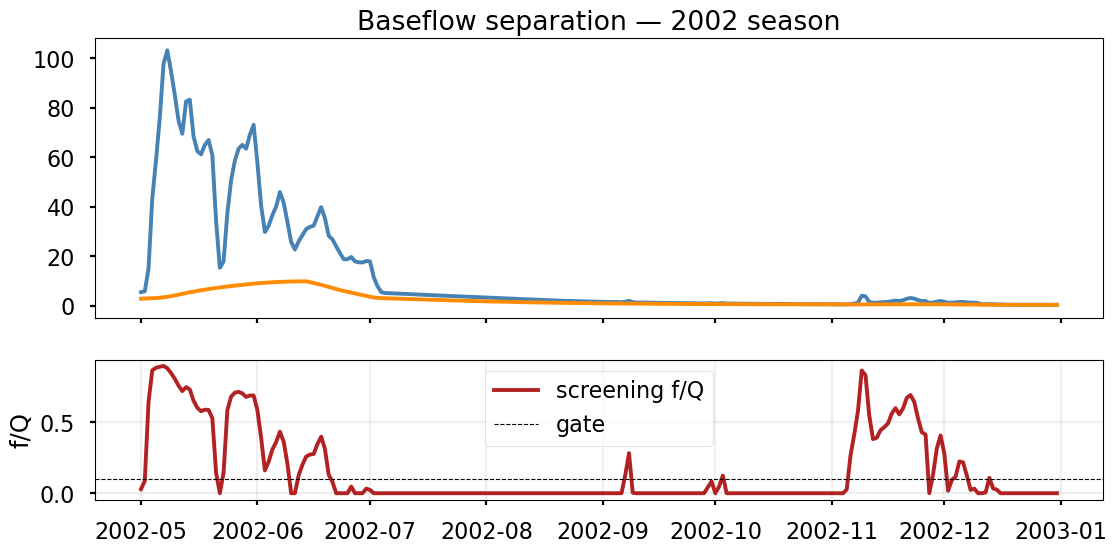

In [92]:
df = mfilter.add_baseflow_columns(df, cfg)

# Zoom to a single recession season for a legible view.
yr = df.index.year[len(df)//2]
win = df.loc[f"{yr}-05-01":f"{yr}-12-31"]

fig, (a0, a1) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a0.plot(win.index, win["Q"], label="Q", color="steelblue")
a0.plot(win.index, win["baseflow"], label="baseflow (multi-pass)", color="darkorange")
# a0.set_yscale("log"); a0.set_ylabel("Q (log)"); a0.legend(); a0.grid(alpha=0.2, which="both")
a0.set_title(f"Baseflow separation — {yr} season")
a1.plot(win.index, win["qf_frac"], color="firebrick", label="screening f/Q")
a1.axhline(cfg.recession.quickflow_frac_max, ls="--", color="k", lw=0.8, label="gate")
a1.set_ylabel("f/Q"); a1.legend(); a1.grid(alpha=0.2)

## 4. Identify recessions & tune the gate

Applies all screens (falling, post-peak drop, quickflow gate, season, forcing
precedence, gap breaks, min length). Inspect the count and metrics table; if too
few/many, adjust `OVERRIDES` (§1) and re-run from there.

In [93]:
recessions = rid.identify_recessions(df, cfg)
result, tails = mmrc.build_mrc(recessions, cfg)
metrics = mmrc.recession_metrics_frame(recessions, tails)

n_conf = int(metrics["conforming"].sum()) if len(metrics) else 0
print(f"{len(recessions)} recession segments  |  {n_conf} conforming (r2 >= {cfg.mrc.min_tail_r2}, k > 0)")
if len(metrics):
    display(metrics.sort_values("length", ascending=False).head(10))

105 recession segments  |  93 conforming (r2 >= 0.3, k > 0)


,seg_id,start,end,length,doy_start,water_year,q_start,q_end,tail_k,tau,tail_r2,n_tail,conforming,flags
95,95,2020-06-23,2020-11-11,142,175,2020,5.164648,0.275082,0.018508,54.031936,0.983848,71,True,
16,16,1987-06-14,1987-10-21,130,165,1987,3.245398,0.102289,0.030793,32.475329,0.999643,66,True,
17,17,1988-06-06,1988-10-10,127,158,1988,3.777095,0.102655,0.034687,28.828993,0.996768,66,True,
0,0,1981-06-06,1981-09-25,112,157,1981,7.043890,0.334294,0.030254,33.053858,0.996652,56,True,
64,64,2007-06-09,2007-09-21,105,160,2007,4.663500,0.569165,0.026294,38.031459,0.997367,42,True,
94,94,2019-08-24,2019-12-01,100,236,2019,4.242787,0.972255,0.040972,24.406821,0.935133,16,True,
31,31,1994-06-19,1994-09-24,98,170,1994,3.829388,0.737230,0.020259,49.361553,0.992006,35,True,
87,87,2016-07-14,2016-10-14,93,196,2016,5.174066,0.951693,0.016609,60.209314,0.997028,34,True,
22,22,1990-07-22,1990-10-18,89,203,1990,3.633555,0.726398,0.015440,64.766540,0.977425,33,True,
78,78,2012-07-18,2012-10-11,86,200,2012,2.985735,0.505319,0.019553,51.142152,0.999485,32,True,


In [94]:
# Alpha-sensitivity: how does recession selection respond to the filter alpha?
rid.alpha_sensitivity(df, cfg)

,alpha,n_segments,total_recession_days,median_length,max_length
0,0.900,112,4216,25.0,148
1,0.925,111,4198,25.0,148
2,0.950,109,4161,26.0,148
3,0.990,102,4009,28.0,142


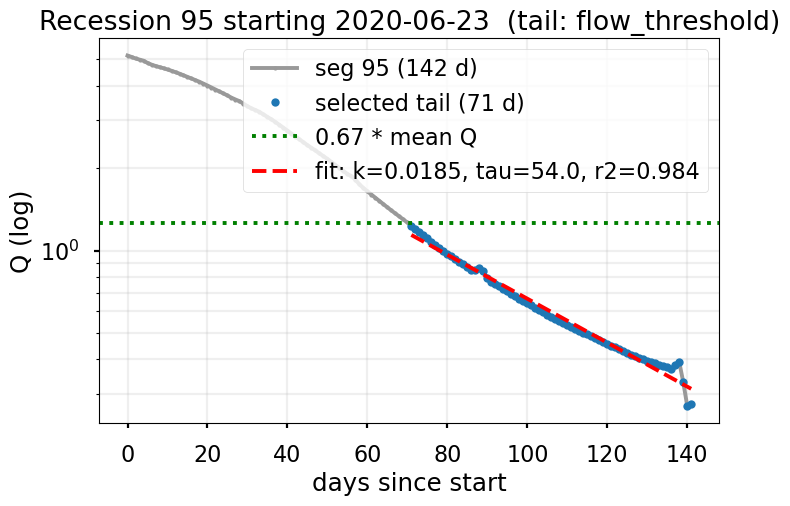

In [95]:
# Inspect a single recession: full limb, the selected tail, and the fit.
# Tail selection follows cfg.mrc.tail_method (flow_threshold = Q < frac * mean Q).
if recessions:
    i = int(np.argmax([r.length for r in recessions]))   # longest one
    r, tf = recessions[i], tails[i]
    tt, qq = mmrc.select_tail_points(
        r.t, r.Q, method=cfg.mrc.tail_method, tail_fraction=cfg.mrc.tail_fraction,
        tail_flow_frac=cfg.mrc.tail_flow_frac, tail_min_points=cfg.mrc.tail_min_points)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(r.t, r.Q, "o-", ms=3, color="0.6", label=f"seg {r.seg_id} ({r.length} d)")
    ax.semilogy(tt, qq, "o", ms=6, color="tab:blue", label=f"selected tail ({tt.size} d)")
    if cfg.mrc.tail_method == "flow_threshold":
        thr = cfg.mrc.tail_flow_frac * float(np.mean(r.Q))
        ax.axhline(thr, ls=":", color="green", label=f"{cfg.mrc.tail_flow_frac:.3g} * mean Q")
    if np.isfinite(tf.k):
        ax.semilogy(tt, np.exp(tf.intercept - tf.k * tt), "r--",
                    label=f"fit: k={tf.k:.4f}, tau={tf.tau:.1f}, r2={tf.r2:.3f}")
    ax.set_xlabel("days since start"); ax.set_ylabel("Q (log)")
    ax.set_title(f"Recession {r.seg_id} starting {r.start.date()}  (tail: {cfg.mrc.tail_method})")
    ax.legend(); ax.grid(alpha=0.2, which="both")

## 4b. Dynamic snowmelt-driven season start (optional)

Instead of a fixed `doy_start`, derive the recession-season start **per water
year** from snow: the first snow-free (meltout) SWE date after the winter peak,
plus a buffer (default 4 weeks). This shifts the season later in big snow years
and earlier in lean ones. Point `SWE_PATH` at a SNOTEL-style daily SWE file
(here: the East River Butte station).

To use it in the main analysis, set `season.mode = "swe_meltout"` and
`season.meltout.swe_path` in `OVERRIDES` (§1), then re-run from §1.

45 water years | 0 fallback | mean start doy = 168


,calendar_year,meltout_date,season_start,doy_start,used_fallback
0,1981,1981-04-27,1981-05-25,145,False
1,1982,1982-05-30,1982-06-27,178,False
2,1983,1983-06-05,1983-07-03,184,False
3,1984,1984-05-31,1984-06-28,180,False
4,1985,1985-05-25,1985-06-22,173,False


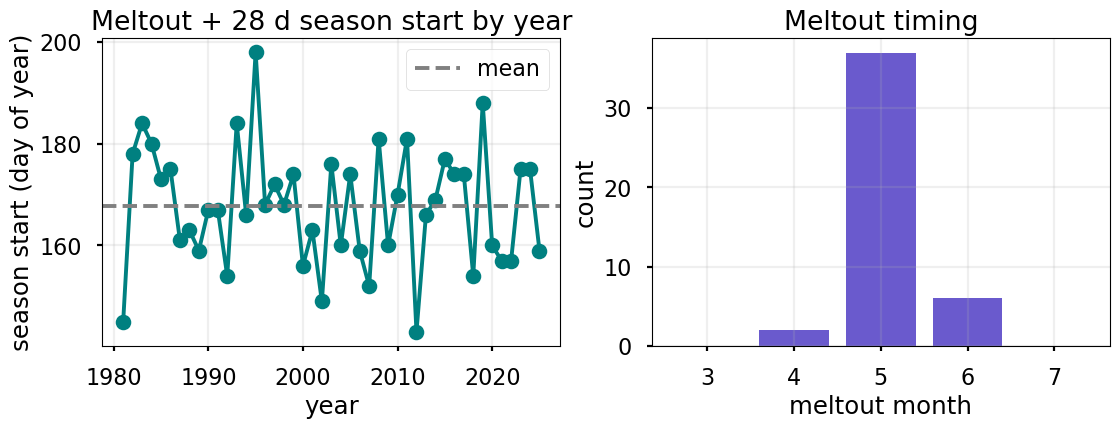

In [96]:
SWE_PATH = "/scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/snow/380_Butte_sntl_obs.csv"

if Path(SWE_PATH).exists():
    cfg_dyn = load_config(overrides={"recession": {"season": {
        "mode": "swe_meltout",
        "meltout": {"swe_path": SWE_PATH, "buffer_days": 28},
    }}})
    season = rid.season_starts_frame(cfg_dyn)
    print(f"{len(season)} water years | {int(season['used_fallback'].sum())} fallback | "
          f"mean start doy = {season['doy_start'].mean():.0f}")
    display(season.head())

    fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
    a0.plot(season["calendar_year"], season["doy_start"], "o-", color="teal")
    a0.axhline(season["doy_start"].mean(), ls="--", color="0.5", label="mean")
    a0.set_xlabel("year"); a0.set_ylabel("season start (day of year)")
    a0.set_title("Meltout + 28 d season start by year"); a0.legend(); a0.grid(alpha=0.2)
    md_month = season["meltout_date"].dropna().dt.month
    a1.hist(md_month, bins=range(3, 9), align="left", rwidth=0.8, color="slateblue")
    a1.set_xlabel("meltout month"); a1.set_ylabel("count"); a1.set_title("Meltout timing")
    a1.grid(alpha=0.2)
else:
    print("SWE file not found; set SWE_PATH to a SNOTEL-style daily SWE CSV to try this.")

## 5. Master recession curve (full record)

Ranked recession traces and the matching-strip master curve. The master is fit
as time-vs-log-flow so free offsets can only slide recessions along time (no
flattening degeneracy).

master k = 0.0285/day   tau = 35.1 d   RMSE = 3.19 d   (used 93/93 conforming)


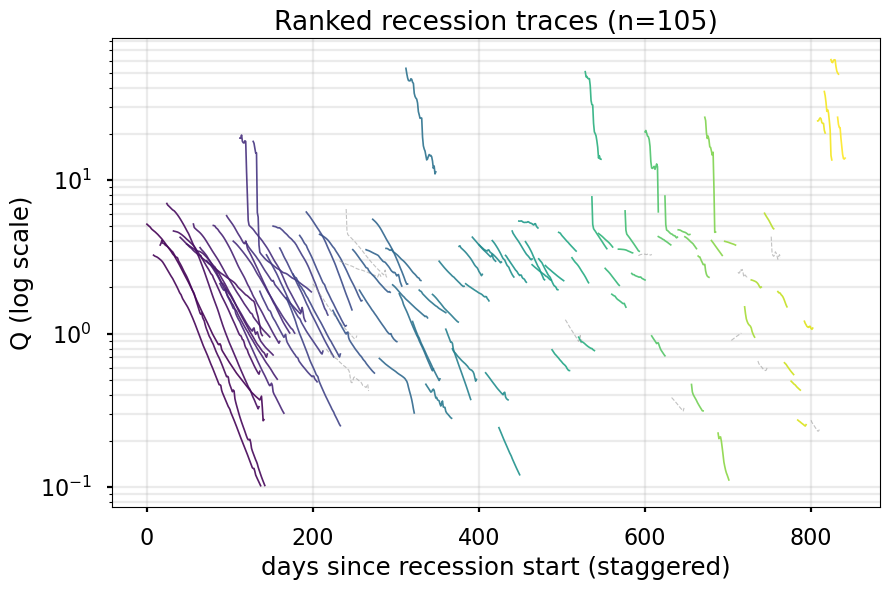

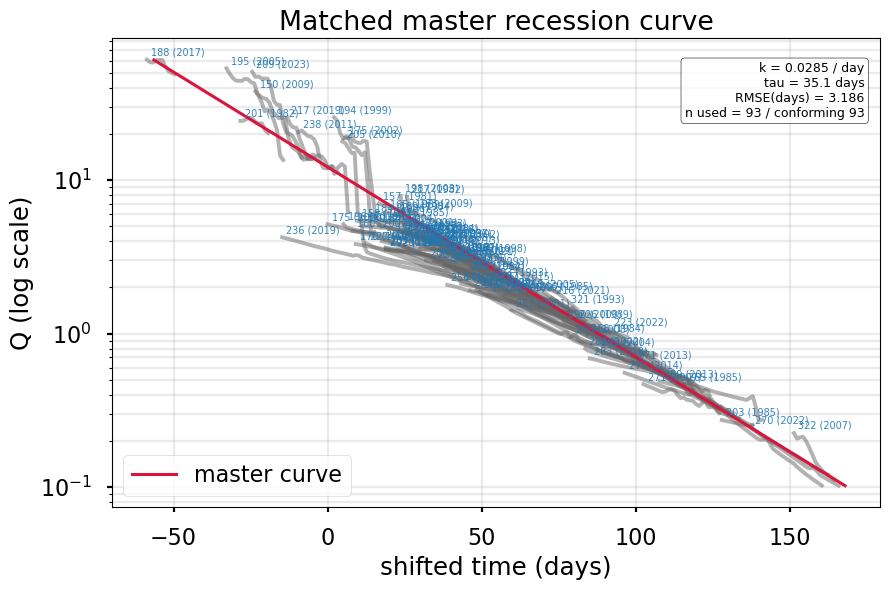

In [97]:
print(f"master k = {result.k:.4f}/day   tau = {result.tau:.1f} d   "
      f"RMSE = {result.rmse:.2f} d   (used {result.n_used}/{result.n_conforming} conforming)")

fig1 = mplot.plot_ranked_recessions(recessions, tails)
fig2 = mplot.plot_matched_mrc(recessions, tails, result, label_starts=True)

## 6. Stationarity of k over time

Master `k` on overlapping windows + Mann-Kendall / Sen-slope trend test. **Read
the caveat**: overlapping windows are autocorrelated, so the p-value is a
screening indicator, not a formal test.

> **Note on the synthetic demo:** no trend is injected into the built-in synthetic
> record, yet the test may report a "significant" trend. That is exactly the
> autocorrelation/sampling artifact the caveat warns about — interannual amplitude
> variation makes the pooled `k` wander, and overlapping windows inflate
> significance. Treat it as a lesson, not a bug. For a defensible test on real
> data, prefer the per-year series or non-overlapping windows.

Trend: no trend   Sen slope = -0.000298/yr   p = 0.266   Kendall tau = -0.357   n = 8

Caveat: Nominal p assumes independent samples. Overlapping windows induce strong positive serial autocorrelation (inflating significance), and per-window sample sizes are unequal (heteroscedastic k estimates). Treat p as a screening indicator, not a formal test.


,window,year_start,year_end,year_mid,n_recessions,k,tau,rmse,n_conforming,n_used
0,1981-1985,1981,1985,1983.0,13,0.030176,33.138433,0.901845,13,13
1,1986-1990,1986,1990,1988.0,10,0.032223,31.033359,2.352055,8,8
2,1991-1995,1991,1995,1993.0,10,0.019612,50.988068,1.261854,8,8
3,1996-2000,1996,2000,1998.0,13,0.179781,5.562333,2.172478,13,13
4,2001-2005,2001,2005,2003.0,14,0.024093,41.505847,1.010660,12,12
5,2006-2010,2006,2010,2008.0,14,0.025970,38.505769,3.087835,13,13
6,2011-2015,2011,2015,2013.0,12,0.024926,40.118597,2.261693,11,11
7,2016-2020,2016,2020,2018.0,10,0.019253,51.938743,2.757810,8,8


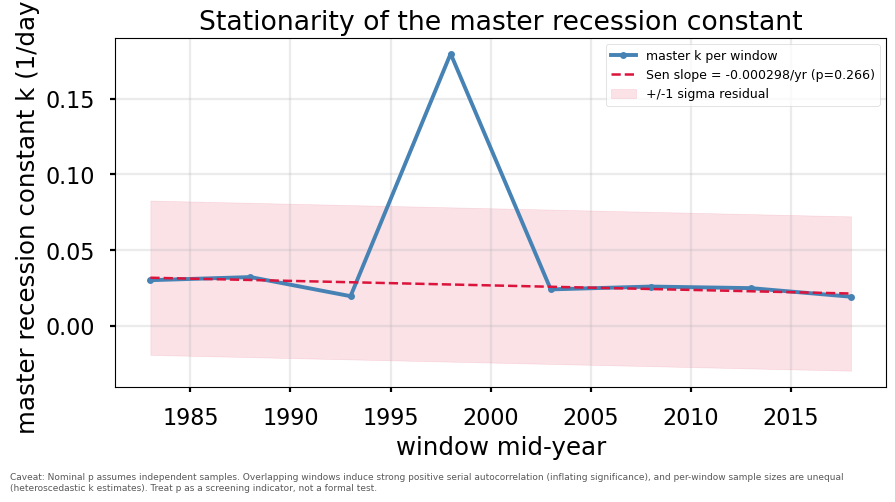

In [98]:
window_df = mtemporal.window_mrc_series(recessions, cfg)
trend = mtemporal.trend_on_windows(window_df, cfg)
print(f"Trend: {trend.trend}   Sen slope = {trend.sen_slope:.4g}/yr   "
      f"p = {trend.p_value:.3f}   Kendall tau = {trend.tau:.3f}   n = {trend.n}")
print("\nCaveat:", trend.caveat)
display(window_df.head(10))

fig3 = mplot.plot_k_timeseries(window_df, trend)

## 6b. Poly-order robustness (apples-to-apples)

Compare the master `k` and its trend for `master_poly_order` **1 vs 2 on identical
samples**. Recession identification and per-recession conformance don't depend on
the master polynomial order (the per-recession tail fit is always linear), so the
same `recessions` feed every order and only the master model differs. Windows
where *any* order returns an invalid/non-monotonic `k` (NaN) are dropped from
*all* orders, so every trend test runs on the same windows, years, and `n_used` —
isolating the effect of the master model from any sampling change.

If poly-2 looks essentially linear (coeffs of the quadratic term ≈ 0) and the two
`k` series track each other, a single linear reservoir is a defensible assumption.
Divergence flags curvature (multi-store behavior) or an unstable edge-derivative
(see the poly-2 τ discussion).

8/8 windows valid across orders [1, 2] | n_used identical across orders: True
poly-1: no trend     Sen=-0.000298/yr  p=0.266  Kendall tau=-0.357  n=8  mean k=0.0445
poly-2: no trend     Sen=-0.000268/yr  p=0.266  Kendall tau=-0.357  n=8  mean k=0.0217


,window,year_mid,k1,tau1,n1,k2,tau2,n2
0,1981-1985,1983.0,0.030176,33.138433,13,0.027096,36.905236,13
1,1986-1990,1988.0,0.032223,31.033359,8,0.039172,25.528135,8
2,1991-1995,1993.0,0.019612,50.988068,8,0.013738,72.790212,8
3,1996-2000,1998.0,0.179781,5.562333,13,0.018623,53.696098,13
4,2001-2005,2003.0,0.024093,41.505847,12,0.021564,46.374188,12
5,2006-2010,2008.0,0.025970,38.505769,13,0.017171,58.238422,13
6,2011-2015,2013.0,0.024926,40.118597,11,0.019323,51.752383,11
7,2016-2020,2018.0,0.019253,51.938743,8,0.016525,60.514379,8


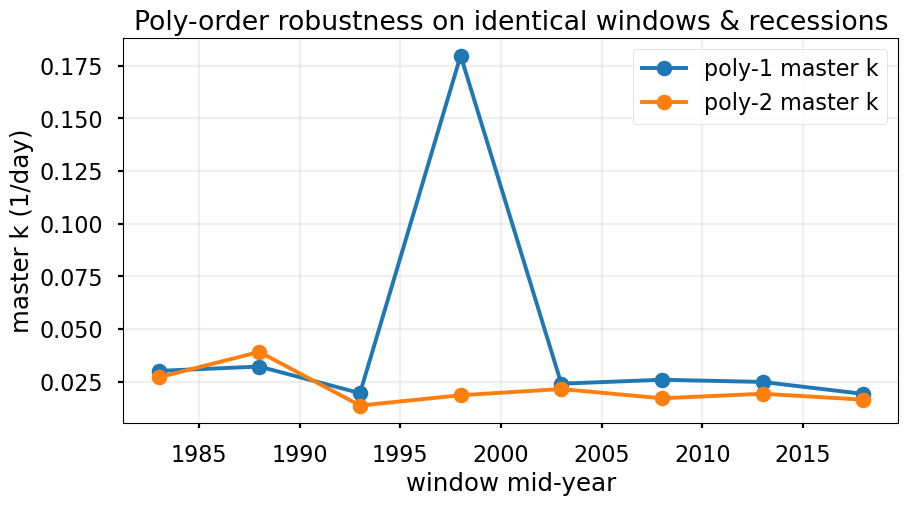

In [99]:
# --- Poly-order robustness: apples-to-apples (same recessions & windows) -----
# Recession identification and per-recession conformance are INDEPENDENT of
# master_poly_order (the per-recession tail fit is always linear), so we reuse the
# same `recessions` for every order and only the master model changes. We then
# compare on windows valid in ALL orders, so any difference is the master model
# alone -- not a change in which recessions/windows were used.
import copy

ORDERS = [1, 2]

def _windows_for_order(order):
    # Derive from CONFIG_PATH so the sweep uses the SAME basin config as `cfg`.
    c = load_config(CONFIG_PATH, overrides={"mrc": {"master_poly_order": order}})
    w = mtemporal.window_mrc_series(recessions, c)
    return w[["window", "year_mid", "k", "tau", "n_used"]].rename(
        columns={"k": f"k{order}", "tau": f"tau{order}", "n_used": f"n{order}"})

merged = _windows_for_order(ORDERS[0])
for o in ORDERS[1:]:
    merged = merged.merge(_windows_for_order(o), on=["window", "year_mid"])

kcols = [f"k{o}" for o in ORDERS]
common = merged.dropna(subset=kcols).copy()
n_match = all((common[f"n{ORDERS[0]}"] == common[f"n{o}"]).all() for o in ORDERS)
print(f"{len(common)}/{len(merged)} windows valid across orders {ORDERS} | "
      f"n_used identical across orders: {n_match}")

for o in ORDERS:
    tr = mtemporal.mann_kendall(common[f"k{o}"].to_numpy(), common["year_mid"].to_numpy())
    print(f"poly-{o}: {tr.trend:11s}  Sen={tr.sen_slope:+.6f}/yr  p={tr.p_value:.3f}  "
          f"Kendall tau={tr.tau:+.3f}  n={tr.n}  mean k={common[f'k{o}'].mean():.4f}")

display(common)

fig, ax = plt.subplots(figsize=(10, 5))
for o in ORDERS:
    ax.plot(common["year_mid"], common[f"k{o}"], "o-", label=f"poly-{o} master k")
ax.set_xlabel("window mid-year"); ax.set_ylabel("master k (1/day)")
ax.set_title("Poly-order robustness on identical windows & recessions")
ax.legend(); ax.grid(alpha=0.2)

## 6c. τ vs tail-depth plateau (n held fixed)

Sweep `tail_flow_frac` ∈ {0.5, 0.65, 0.75, 0.85} and watch τ converge. Tail depth
changes which points enter each fit, which changes r² and therefore *which*
recessions conform — so the raw conforming count drifts (printed below). To keep
the comparison honest we fix the sample to the **intersection** (recessions
conforming at every frac) and compute τ on that identical set at each depth; the
`assert` guarantees `n_used` never moves. Any remaining τ change is fit geometry,
not sample composition.

**Reading the plateau:** where τ flattens, that flat value is the converged
late-limb recession constant; the shallow-cut point that sits off the plateau is
early-limb / fallback-contaminated and should not be used. The poly-1 master τ and
the median per-recession τ are the ones to trust — poly-2's grey line reads τ off
the polynomial's edge derivative and typically keeps drifting (no plateau), which
is why poly-1 is preferred for the reported constant.

raw conforming per frac: {0.25: 90, 0.5: 93, 0.65: 93, 0.75: 95, 0.85: 96}  <- drifts with tail depth
FIXED intersection set: n = 90 (held constant across the sweep)


,tail_flow_frac,n_used,tau_master_p1,tau_master_p2,tau_median_tail
0,0.25,90,26.251172,35.683484,57.518746
1,0.50,90,32.858108,36.597126,57.817029
2,0.65,90,34.527705,34.411400,56.269098
3,0.75,90,35.685491,32.663790,54.786111
4,0.85,90,36.769986,30.789126,54.786111


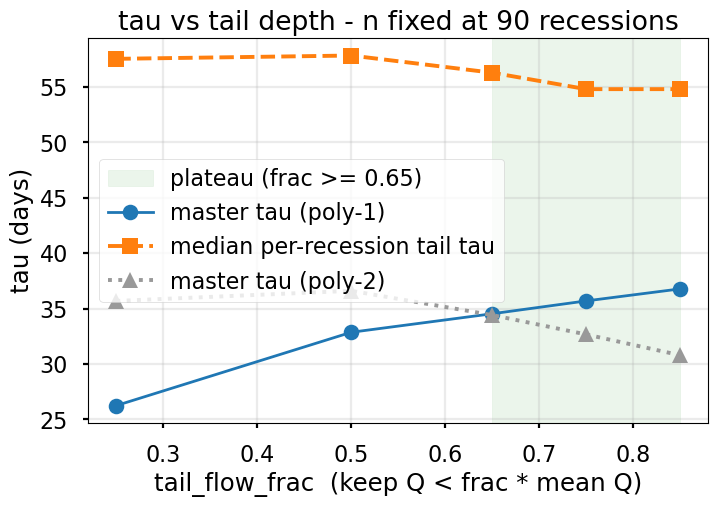

In [100]:
# --- tau vs tail-depth plateau (n held FIXED across the sweep) ---------------
import copy
FRACS = [0.25,0.5, 0.65, 0.75, 0.85]

def _cfg_frac(frac, order=1):
    return load_config(CONFIG_PATH, overrides={
        "mrc": {"tail_flow_frac": frac, "master_poly_order": order}})

# Raw conforming set at each frac exposes sample drift (r2, hence conformance,
# depends on which points sit in the tail). We then fix the sample to the
# INTERSECTION -- recessions conforming at every frac -- so the tau curve reflects
# fit geometry, not sample composition.
conf = {f: {r.seg_id for r, tf in zip(recessions, mmrc.fit_all_tails(recessions, _cfg_frac(f)))
            if tf.conforming} for f in FRACS}
fixed_ids = set.intersection(*conf.values())
sub = [r for r in recessions if r.seg_id in fixed_ids]
print("raw conforming per frac:", {f: len(conf[f]) for f in FRACS}, " <- drifts with tail depth")
print(f"FIXED intersection set: n = {len(sub)} (held constant across the sweep)")

rows = []
for f in FRACS:
    r1, t1 = mmrc.build_mrc(sub, _cfg_frac(f, 1))
    r2, _  = mmrc.build_mrc(sub, _cfg_frac(f, 2))
    med = np.median([tf.tau for tf in t1 if np.isfinite(tf.tau)])
    rows.append({"tail_flow_frac": f, "n_used": r1.n_used,
                 "tau_master_p1": r1.tau, "tau_master_p2": r2.tau, "tau_median_tail": med})
sweep = pd.DataFrame(rows)
assert (sweep["n_used"] == len(sub)).all(), "n drifted across the sweep!"
display(sweep)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(0.65, 0.85, color="green", alpha=0.08, label="plateau (frac >= 0.65)")
ax.plot(sweep.tail_flow_frac, sweep.tau_master_p1, "o-", lw=2, label="master tau (poly-1)")
ax.plot(sweep.tail_flow_frac, sweep.tau_median_tail, "s--", label="median per-recession tail tau")
ax.plot(sweep.tail_flow_frac, sweep.tau_master_p2, "^:", color="0.6", label="master tau (poly-2)")
ax.set_xlabel("tail_flow_frac  (keep Q < frac * mean Q)"); ax.set_ylabel("tau (days)")
ax.set_title(f"tau vs tail depth - n fixed at {len(sub)} recessions")
ax.legend(); ax.grid(alpha=0.25)

,buffer_days,n_rec,n_conf,rec_days,master_tau,median_tau
0,0,99,88,3549,35.236249,56.269098
1,7,98,87,3525,35.115949,56.467545
2,14,98,87,3511,35.025498,56.467545
3,21,98,87,3497,34.940146,56.467545
4,28,98,87,3464,35.002975,56.467545
5,35,98,87,3425,35.097990,56.902523
6,42,97,86,3355,35.417779,56.685034


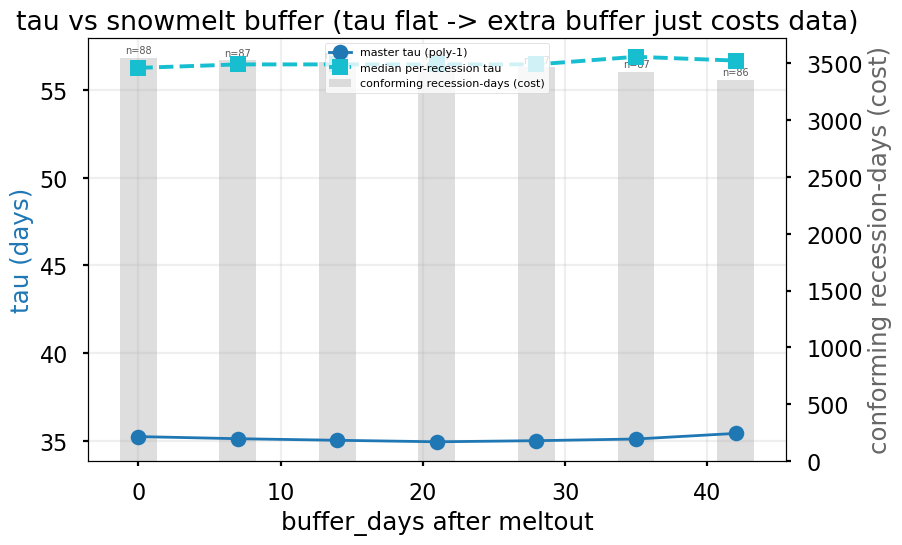

In [101]:
# --- tau vs snowmelt buffer_days (season start = meltout + buffer) -----------
# Unlike the tail sweep, buffer_days shifts the SEASON START, so it changes which
# recession segments are identified -> n moves BY DESIGN. That trade-off is the
# thing under test: does a longer buffer lengthen/stabilize tau (removing melt-
# contaminated limb), or just shed recessions/record for no tau gain? So we plot
# tau against its cost (conforming recession-days), rather than holding n fixed.
import copy
BUFFERS = [0, 7, 14, 21, 28, 35, 42]

def _cfg_buffer(b):
    return load_config(CONFIG_PATH, overrides={
        "recession": {"season": {"meltout": {"buffer_days": b}}}})

rows = []
for b in BUFFERS:
    c = _cfg_buffer(b)
    recs_b = rid.identify_recessions(df, c)          # df is buffer-independent
    res_b, tails_b = mmrc.build_mrc(recs_b, c)
    conf = [tf for tf in tails_b if tf.conforming]
    rec_days = sum(r.length for r, tf in zip(recs_b, tails_b) if tf.conforming)
    med = np.median([tf.tau for tf in conf if np.isfinite(tf.tau)]) if conf else np.nan
    rows.append({"buffer_days": b, "n_rec": len(recs_b), "n_conf": len(conf),
                 "rec_days": rec_days, "master_tau": res_b.tau, "median_tau": med})
bsweep = pd.DataFrame(rows)
display(bsweep)

fig, axL = plt.subplots(figsize=(9, 5.5))
axR = axL.twinx()
axR.bar(bsweep.buffer_days, bsweep.rec_days, width=2.6, color="0.75", alpha=0.5,
        label="conforming recession-days (cost)")
for x, y, n in zip(bsweep.buffer_days, bsweep.rec_days, bsweep.n_conf):
    axR.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(0, 3),
                 ha="center", fontsize=7, color="0.35")
axL.plot(bsweep.buffer_days, bsweep.master_tau, "o-", color="tab:blue", lw=2, label="master tau (poly-1)")
axL.plot(bsweep.buffer_days, bsweep.median_tau, "s--", color="tab:cyan", label="median per-recession tau")
axL.set_xlabel("buffer_days after meltout"); axL.set_ylabel("tau (days)", color="tab:blue")
axR.set_ylabel("conforming recession-days (cost)", color="0.4")
axL.set_zorder(axR.get_zorder() + 1); axL.patch.set_visible(False)
axL.grid(alpha=0.2); axL.set_title("tau vs snowmelt buffer (tau flat -> extra buffer just costs data)")
h1, l1 = axL.get_legend_handles_labels(); h2, l2 = axR.get_legend_handles_labels()
axL.legend(h1 + h2, l1 + l2, loc="upper center", fontsize=8)

## 6e. Brutsaert–Nieber: −dQ/dt vs Q (independent linearity + drought test)

Plot the recession rate −dQ/dt against Q on log-log axes for **every** screened
recession day and fit −dQ/dt = a·Q^b. **b is the diagnostic:** b ≈ 1 is a linear
reservoir (constant τ = 1/a — the MRC assumption); b > 1 is nonlinear
storage–discharge. The physical signal is the **lower envelope** (points above it
carry ongoing rain/melt input); we fit a low quantile per log-Q bin.

- **Panel A** (`plot_bn`): if the envelope's slope sits on the b = 1 line, that is
  an *independent* confirmation of the linear reservoir — stronger than the
  poly-order argument alone (two methods agreeing on linearity).
- **Panel B** (`plot_bn_split`): split by wetness state. Separated envelopes
  (same b, different intercept → different effective τ) = the lumped τ drifts with
  storage state without breaking linearity (the drought mechanism). Overlapping
  envelopes = τ stationary w.r.t. wetness → drought hypothesis fails for this basin.
  Run it per basin: does connected Tuolumne separate while disconnected East River
  does not?

**Caveats — read before leaning on a number.** −dQ/dt from daily data is
finite-difference noisy near the flat low-Q tail (you'll see horizontal
discretization stripes and the envelope flattening at low Q), and the fitted b
shifts with envelope choice. The robustness cell below sweeps method/quantile:
**b stays near 1 (linearity is robust) but the τ magnitude moves a lot** — so lean
on the b-vs-1 comparison, treat b as a range not a point, and don't over-read the
envelope τ. This is idealized only in textbook figures; real clouds are messy.

cloud points: 3791  |  reference flow Q = 1.96


,group,b,a,tau_ref_days,q_ref,r2,n_fit_points,n_cloud,method
0,overall,0.683468,0.008910,138.867993,1.959782,0.713104,20,3791,lower_quantile
1,dry,0.615266,0.009317,139.041015,1.959782,0.676958,20,1190,lower_quantile
2,wet,0.788536,0.009816,117.448043,1.959782,0.737423,13,419,lower_quantile


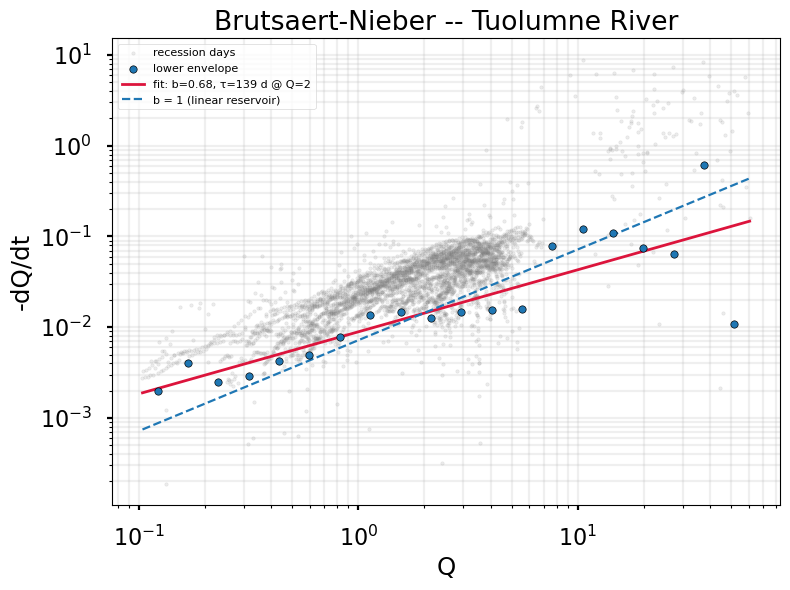

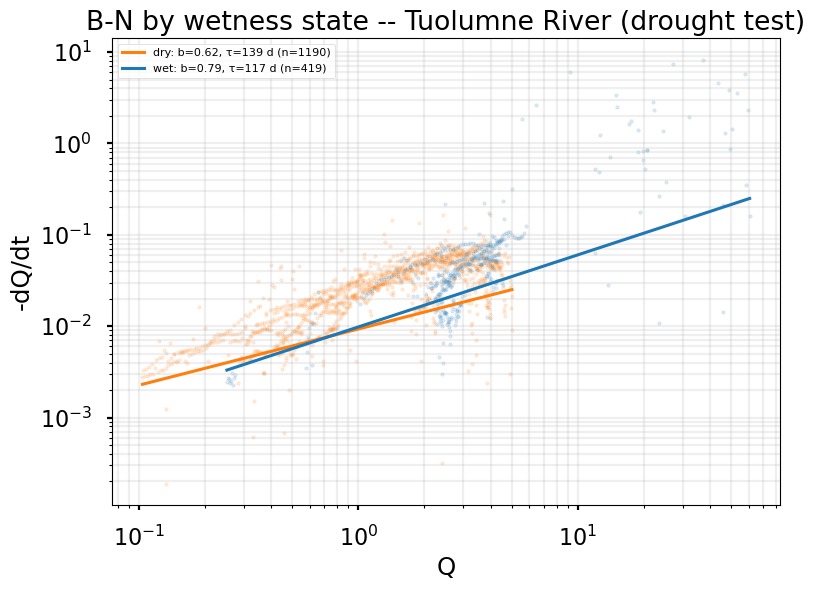

In [102]:
from mrc import bn as mbn

bn_res = mbn.bn_analysis(recessions, cfg, df=df)
print(f"cloud points: {len(bn_res.cloud)}  |  reference flow Q = {bn_res.q_ref:.3g}")
display(mbn.fits_frame(bn_res))

figA = mplot.plot_bn(bn_res, title="Brutsaert-Nieber -- Tuolumne River")
if bn_res.groups:
    figB = mplot.plot_bn_split(bn_res, title="B-N by wetness state -- Tuolumne River (drought test)")

In [26]:
# Robustness: b and (especially) tau shift with envelope choice -- the honest
# caveat. Sweep method/quantile and read b as a RANGE, not a point.
import copy
rows = []
for method in ["lower_quantile", "ols_cloud"]:
    quants = [0.02, 0.05, 0.10] if method == "lower_quantile" else [None]
    for q in quants:
        env = {"method": method}
        if q is not None:
            env["quantile"] = q
        c = load_config(CONFIG_PATH, overrides={"bn": {"envelope": env}})
        f = mbn.bn_analysis(recessions, c, df=df).overall
        rows.append({"method": method, "quantile": q, "b": round(f.b, 3),
                     "tau_ref_d": round(f.tau_ref, 1), "r2": round(f.r2, 3), "n_cloud": f.n_cloud})
print("b stays near 1 across choices (linearity robust); tau_ref moves a lot (low-Q FD noise):")
display(pd.DataFrame(rows))

b stays near 1 across choices (linearity robust); tau_ref moves a lot (low-Q FD noise):


,method,quantile,b,tau_ref_d,r2,n_cloud
0,lower_quantile,0.02,1.105,254.2,0.700,3323
1,lower_quantile,0.05,1.098,131.8,0.756,3323
2,lower_quantile,0.10,1.159,85.5,0.904,3323
3,ols_cloud,NaN,1.377,50.1,0.775,3323


### Wetness-split variants (extreme years, era)

The median split balances point counts but blurs the contrast. Sharpen it two
ways: the **driest-10 vs wettest-10** water years by annual flow volume (extreme
tails, middle years dropped), and a **pre-2012 vs 2012–end** era split. If dry years sit on a *lower-τ* envelope than wet,
that is the drought signal the median split averaged away — on East River the
extremes give dry τ ≈ 76 d vs wet τ ≈ 129 d.

--- extremes: driest 10 / wettest 10 years (annual volume) ---
--- era: pre-2012 / 2012-end ---


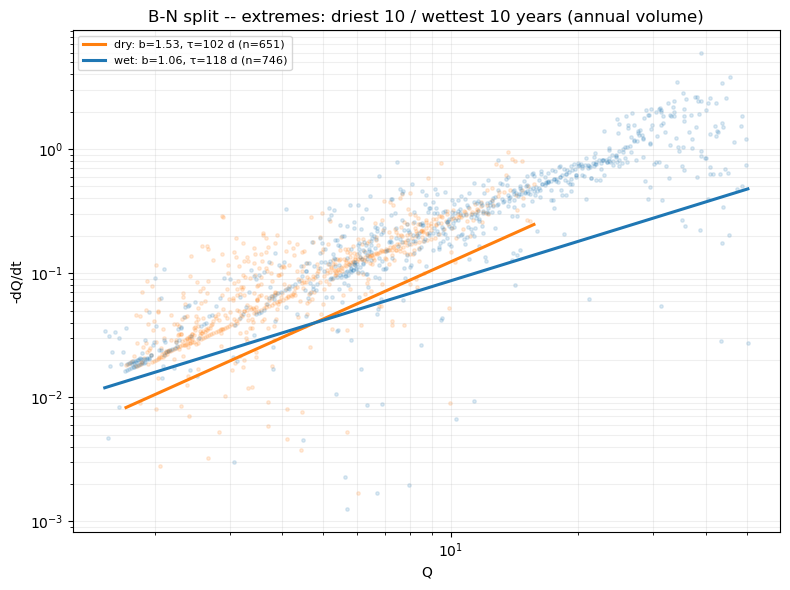

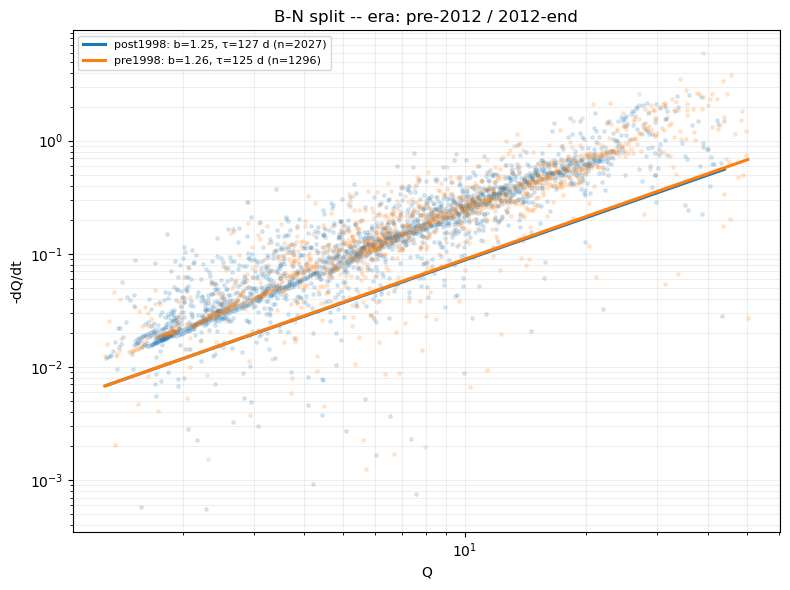

In [27]:
# Wetness-split variants. The median split balances point counts but blurs the
# contrast; sharpen it with the extreme tails and an era split.
for desc, wet in [("extremes: driest 10 / wettest 10 years (annual volume)",
                   {"split": "extremes", "n_extreme": 10}),
                  ("era: pre-2012 / 2012-end", {"split": "era", "split_year": 1998})]:
    c = load_config(CONFIG_PATH, overrides={"bn": {"wetness": {
        "enabled": True, "metric": "water_year_mean_flow", **wet}}})
    res_v = mbn.bn_analysis(recessions, c, df=df)
    print(f"--- {desc} ---")
    mbn.fits_frame(res_v)[["group", "b", "tau_ref_days", "r2", "n_cloud"]]
    mplot.plot_bn_split(res_v, title=f"B-N split -- {desc}")

## 6f. Cross-basin overlay: master recession curves

Build each basin from its own YAML (`config/east_river.yaml`, `config/tuolumne.yaml`)
and overlay the two master curves. This section is **independent of `CONFIG_PATH`** —
it loads both configs itself, so it does not matter which basin the rest of the
notebook is pointed at.

**Why the curves are normalized.** The two basins cannot be overlaid raw: East River
peaks near 49 cms while Tuolumne reaches ~1000, and each matching strip picks an
arbitrary time origin from its own reference recession. `normalize=True` (default)
anchors each master at its own high-flow start (`t = 0`, `Q/Q₀ = 1`), so both curves
leave the same point and the **semilog slope is exactly −k** — which is the quantity
being compared. Pass `normalize=False` for raw `Q` vs shifted time (only meaningful
for a single basin).

Faint traces are each basin's used recessions at their matched offsets; those extending
left of `x = 0` are recessions whose offsets place them upstream of the master's start
(expected, not an artifact).

> **Caveat:** the τ contrast is only fair if the two configs screen recessions
> equally. Check the printed `min_tail_r2` — a looser value admits noisier tails.

East River       1980-10-01..2025-09-30  k=0.0356/d  tau= 28.1 d  n_used= 68  RMSE=2.38 d  min_tail_r2=0.3
Tuolumne         1980-12-02..2023-09-30  k=0.0607/d  tau= 16.5 d  n_used= 47  RMSE=1.46 d  min_tail_r2=0.3
East River (model) 1981-01-01..2025-12-31  k=0.0179/d  tau= 55.7 d  n_used=116  RMSE=1.14 d  min_tail_r2=0.3
Tuolumne (model) 1981-01-01..2023-09-30  k=0.0286/d  tau= 35.0 d  n_used= 87  RMSE=3.05 d  min_tail_r2=0.3


(0.01, 3)

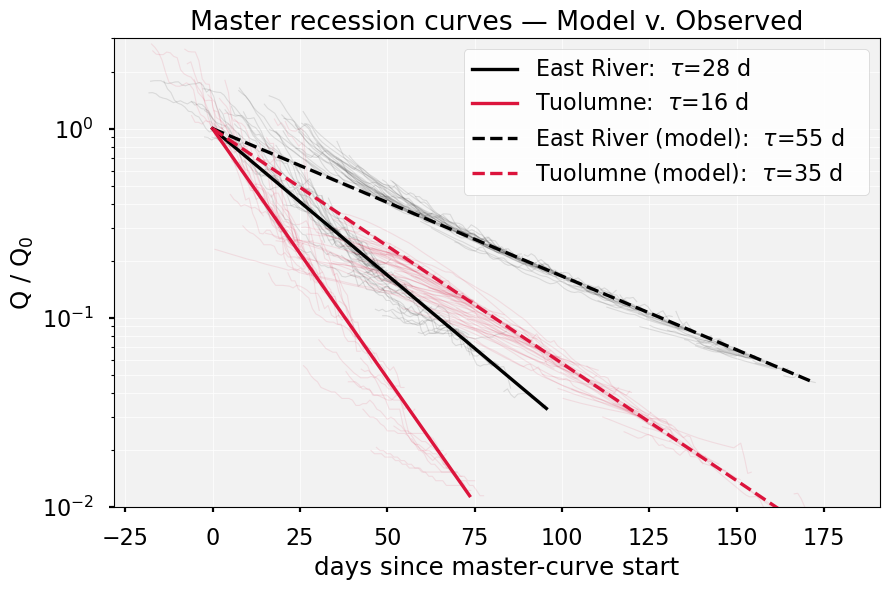

In [49]:
# --- Cross-basin overlay: master recession curves ---------------------------
from pathlib import Path

BASINS = [("east_river", "East River"), ("tuolumne", "Tuolumne"),
          ("east_river_model", "East River (model)"),
          ("tuolumne_model", "Tuolumne (model)")]

entries = []
for _name, _lab in BASINS:
    _c = load_config(PKG / "config" / f"{_name}.yaml")
    rid._MELTOUT_CACHE.clear()          # meltout is cached per SWE config
    _d = mfilter.add_baseflow_columns(
        mio.merge_forcing(mio.load_streamflow(_c), mio.load_forcing(_c)), _c)
    _rs = rid.identify_recessions(_d, _c)
    _res, _tls = mmrc.build_mrc(_rs, _c)
    entries.append((_lab, _rs, _tls, _res))
    print(f"{_lab:16s} {_d.index.min().date()}..{_d.index.max().date()}  "
          f"k={_res.k:.4f}/d  tau={_res.tau:5.1f} d  n_used={_res.n_used:3d}  "
          f"RMSE={_res.rmse:.2f} d  min_tail_r2={_c.mrc.min_tail_r2}")
plt.style.use("seaborn-v0_8-poster")
fig_overlay = mplot.plot_mrc_overlay(
    entries, title="Master recession curves — Model v. Observed",
    linestyles=("-", "-", "--", "--"),
    colors=("black", "crimson", "black", "crimson"))
plt.ylim(0.01,3)


## 7. Commit to the full batch run

Happy with the settings? Run the full pipeline to write tidy tables + figures +
the resolved-config snapshot under `<output_dir>/<label>/`. This repeats the
stages above and persists everything. (Equivalent CLI:
`python -m mrc.cli run --config your_config.yaml`.)

In [13]:
from mrc import cli as mcli

# Uncomment to write outputs:
# results = mcli.run_pipeline(cfg, outdir="outputs/notebook_run")
# print("Wrote outputs to outputs/notebook_run")
print("Ready. Uncomment the run_pipeline line above to write tables + figures.")

Ready. Uncomment the run_pipeline line above to write tables + figures.
